In [2]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (8,4)
print(plt.rcParams["font.family"])

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False

['AppleGothic']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_set = pd.read_csv("datas_ml/water_potability.csv")
data_set

# 마실 수 있는 물의 조건은 무엇인가?

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [6]:
data_set.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


<Figure size 800x400 with 0 Axes>

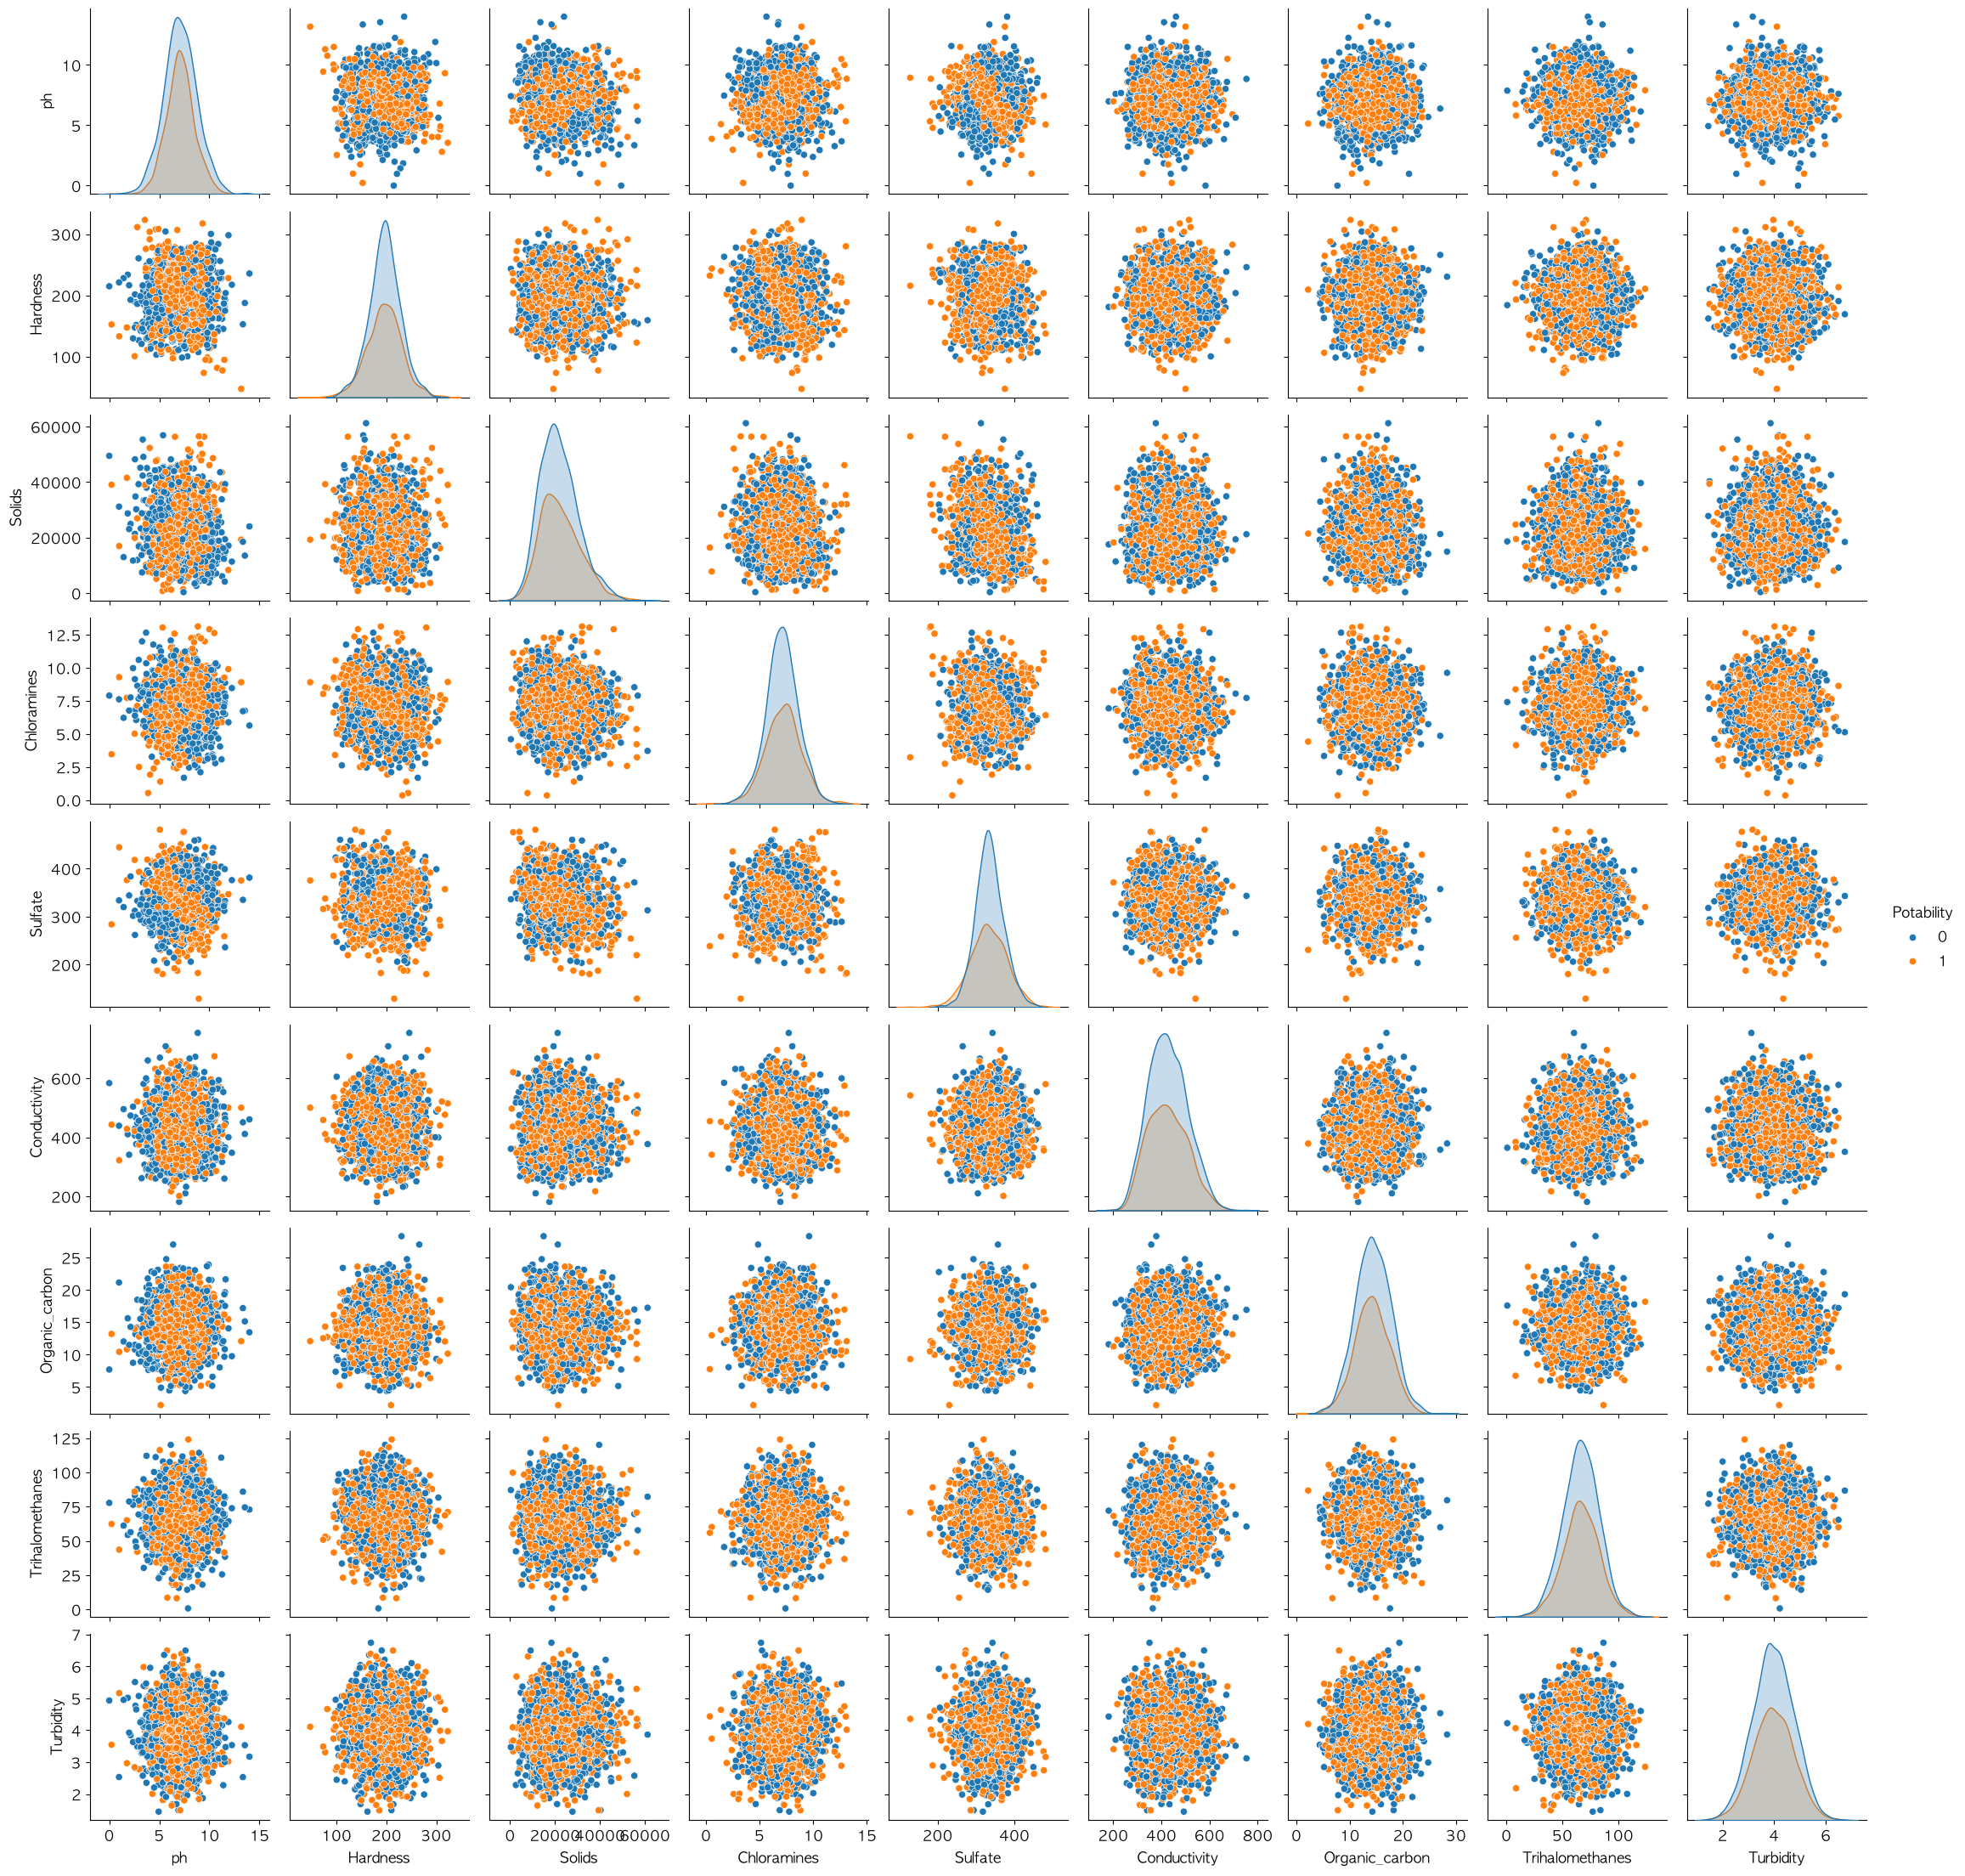

In [25]:
plt.figure()
sns.pairplot(data=data_set, hue="Potability")
plt.show()

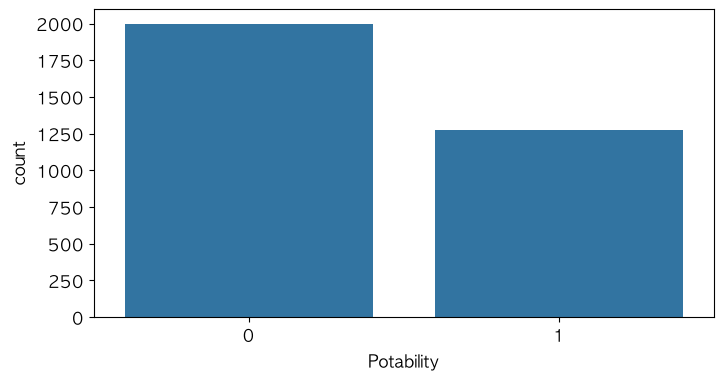

In [26]:
sns.countplot(data=data_set, x="Potability")
plt.show()

In [38]:
except_potability_columns = data_set.select_dtypes(exclude=int).columns

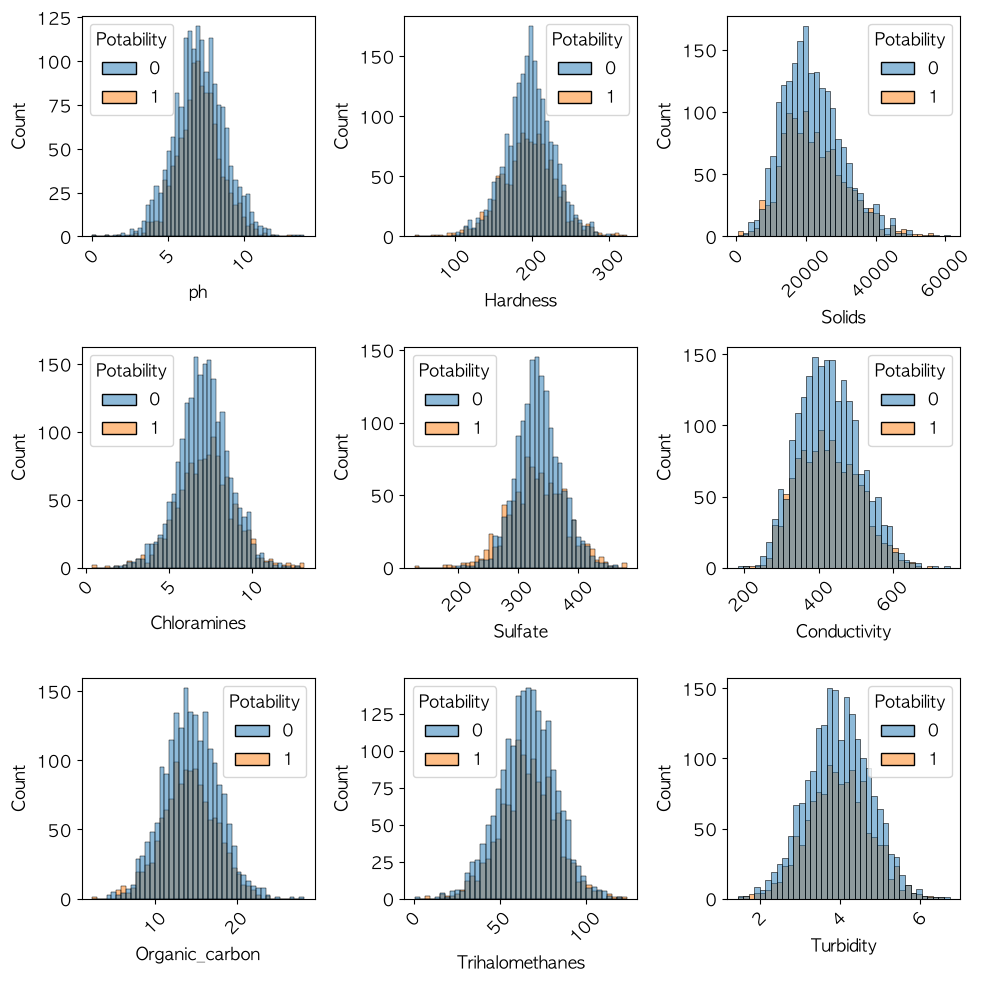

In [50]:
nrows, ncols = 3, 3
figure, axs = plt.subplots(nrows=nrows, ncols=ncols);
figure.set_size_inches(10,10)
axs = axs.flatten()

for i, column in enumerate(except_potability_columns):
    fig = sns.histplot(data=data_set, x=column, hue="Potability", ax=axs[i])
    plt.setp(fig.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

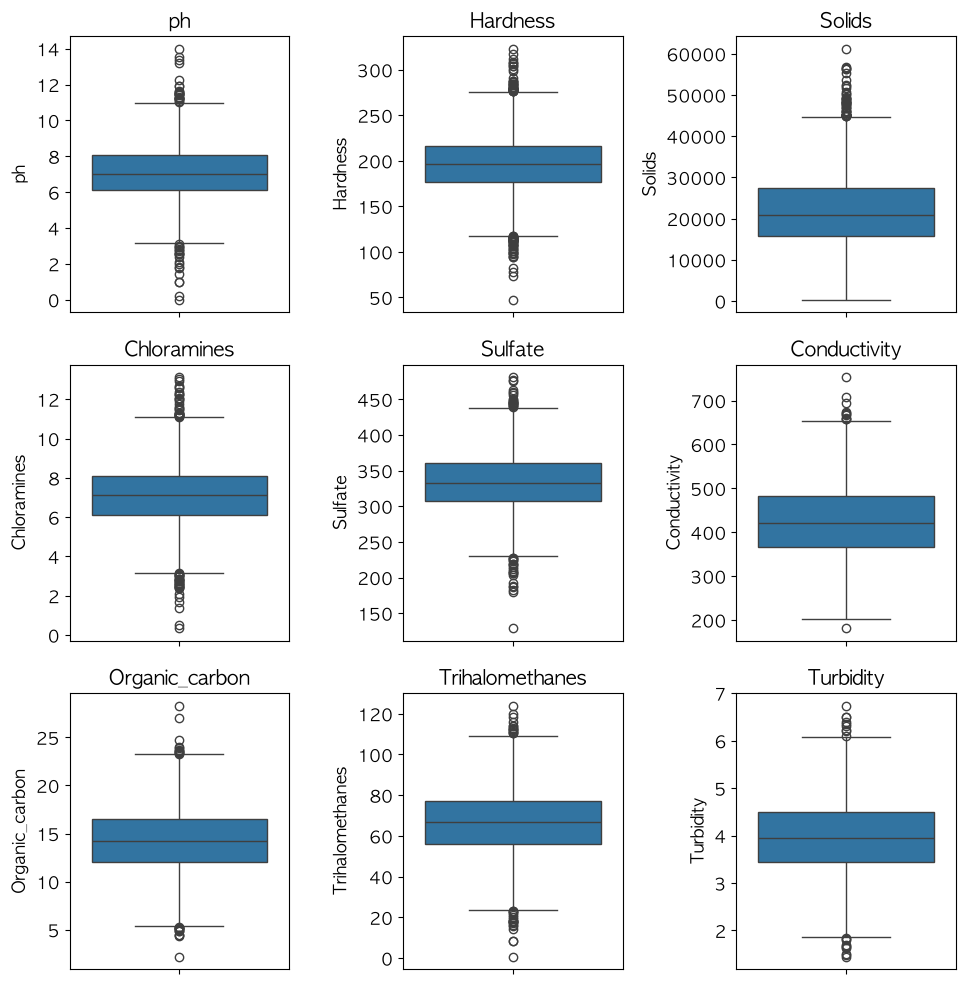

In [ ]:
nrows, ncols = 3, 3
figure, axs = plt.subplots(nrows=nrows, ncols=ncols);
figure.set_size_inches(10,10)
axs = axs.flatten()

for i, column in enumerate(except_potability_columns):
    fig = sns.boxplot(data=data_set, y=column, ax=axs[i])
    fig.set_title(f"{column}")
    plt.setp(fig.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# 오차범위가 발생하는 경우들은 제외를 해주어야 하기 때문에 데이터를 한 번 정제해줘야할 필요가 있다는 것을 확인할 수 있음

In [59]:
corr_df = data_set.corr(numeric_only=True)

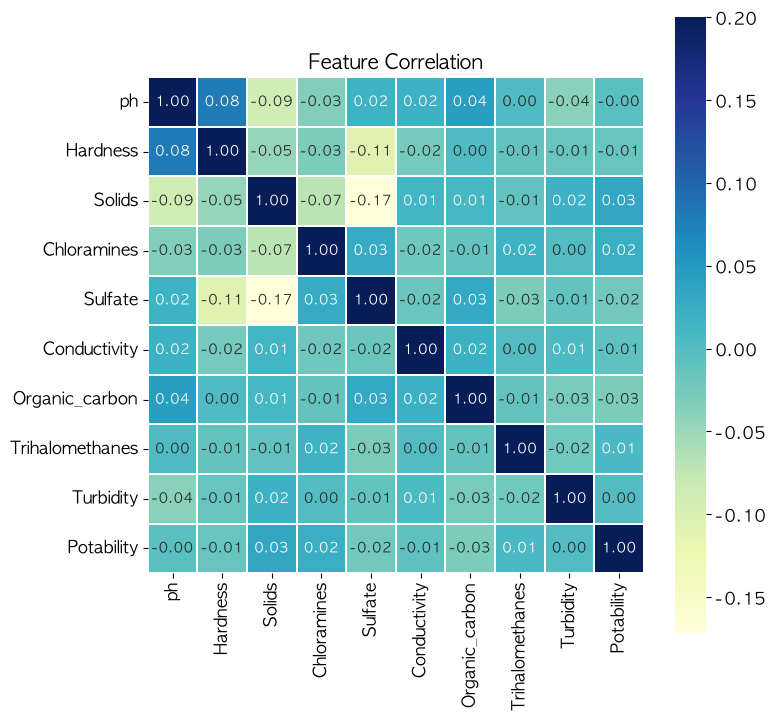

In [ ]:
plt.figure(figsize=(8, 8));
sns.heatmap(corr_df,
            vmax=0.2,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 10},  # annot 글자크기
            cmap='YlGnBu');
plt.title('Feature Correlation');

# 이 히트맵에서 확인해야 하는 정보는 마실 수 있는 물에 대한 정보인 Potability 의 상관계수가 높은 정보는 어떠한 feature가 있는지, 그리고 이 feature 들이 target에 유의미한 영향을 미치는지에 대해서 파악해야 한다.
# 하지만 현재 정보만으로는 어떠한 관계가 Potability 에 강한 영향을 미치는지는 알 수 없기 때문에 추가적인 분석이 필요하다는 것을 알 수 있다.

In [61]:
data_set.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [65]:
data_set.shape

(3276, 10)

In [ ]:
drop_row = data_set.dropna()

In [67]:
drop_row.shape, drop_row.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


((2011, 10), None)

In [74]:
X = drop_row.select_dtypes(exclude=int)
y = drop_row["Potability"]
X.shape, y.shape

((2011, 9), (2011,))

In [76]:
X.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
dtypes: float64(9)
memory usage: 157.1 KB


In [79]:
from sklearn.preprocessing import RobustScaler

transformer = RobustScaler().fit(X)
X_scaled = transformer.transform(X)
x_cols = X.columns
x_cols

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='str')

In [80]:
x_scaled_df = pd.DataFrame(X_scaled, columns=x_cols)
x_scaled_df.head(3)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.656805,0.432827,0.093794,0.464487,0.476884,-0.520252,0.902513,1.583910,0.616651
1,1.051792,-0.405337,-0.255429,-0.303074,-0.427413,-0.216479,-0.606224,-1.618810,0.099787
2,-0.735115,-0.223662,0.675649,0.203448,-0.107428,-1.235928,-1.299047,-0.544739,-1.314778


<Axes: xlabel='Potability', ylabel='count'>

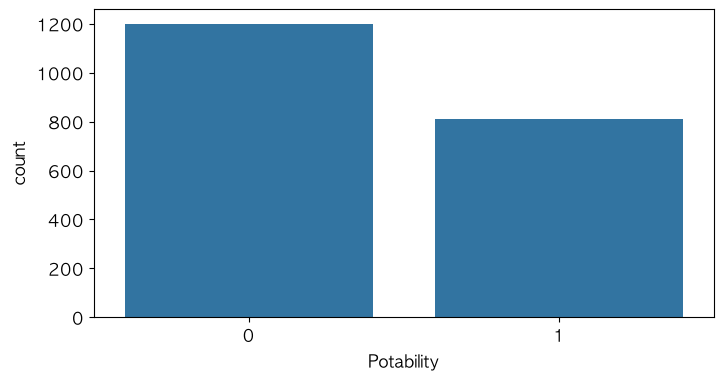

In [81]:
sns.countplot(x=y)

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_scaled_df, y, test_size=0.2, random_state=2024)

X_test.shape

(403, 9)

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

param = {
    "n_neighbors" : [2, 4, 6, 8, 10],
    "p" : [1, 2],
    "cv" : 3
}
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.6451612903225806

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       228
           1       0.61      0.51      0.55       175

    accuracy                           0.65       403
   macro avg       0.64      0.63      0.63       403
weighted avg       0.64      0.65      0.64       403



In [100]:
from sklearn.model_selection import GridSearchCV

In [105]:
params = {'n_neighbors': [2, 4, 6, 8, 10], 'p': [1, 2]}
grid_cv = GridSearchCV(estimator=model ,param_grid=params, n_jobs=-1, cv=3)
grid_cv.fit(X_train, y_train)
grid_cv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla...n_neighbors=3)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 4, ...], 'p': [1, 2]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [106]:
print(f"Best score of paramter search is: {grid_cv.best_score_:.4f}")
print("Best parameter of best score is")
print(f"\t n_neighbors: {grid_cv.best_params_['n_neighbors']}")
print(f"\t p: {grid_cv.best_params_['p']}")

Best score of paramter search is: 0.6542
Best parameter of best score is
	 n_neighbors: 6
	 p: 1


In [118]:
from sklearn.metrics import classification_report

test_pred = grid_cv.predict(X_train)
test_acc = accuracy_score(y_train, test_pred)

print(f"test accuracy is {test_acc:.4f}")

test accuracy is 0.7270


In [120]:
from sklearn.metrics import classification_report

print(classification_report(y_train, test_pred))

              precision    recall  f1-score   support

           0       0.70      0.94      0.81       972
           1       0.82      0.40      0.53       636

    accuracy                           0.73      1608
   macro avg       0.76      0.67      0.67      1608
weighted avg       0.75      0.73      0.70      1608



In [122]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)

train_pred = xgb_clf.predict(X_train)
test_pred = xgb_clf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")

train accuracy is 1.0000
test accuracy is 0.6749


In [123]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.67      0.83      0.74       228
           1       0.68      0.47      0.56       175

    accuracy                           0.67       403
   macro avg       0.68      0.65      0.65       403
weighted avg       0.68      0.67      0.66       403



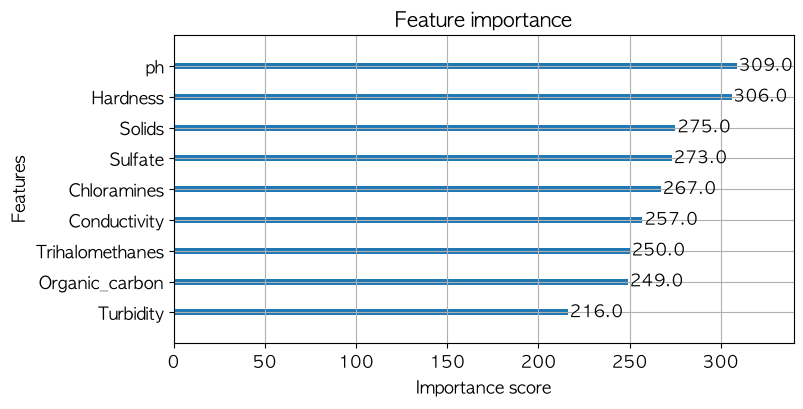

In [126]:
from xgboost import plot_importance
from matplotlib import pyplot

plot_importance(xgb_clf)
pyplot.show()

In [139]:
xgb_clf = XGBClassifier()

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_cv = GridSearchCV(
    estimator=xgb_clf,
    param_grid=params,
    cv=3,
    n_jobs=-1
)

grid_cv.fit(X_train, y_train)

y_pred = grid_cv.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)

print(grid_cv.best_params_)
print(f"test accuracy is {test_acc:.4f}")

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
test accuracy is 0.6700


In [140]:
train_pred = grid_cv.predict(X_train)
test_pred = grid_cv.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")

train accuracy is 0.7494
test accuracy is 0.6700
